## Annual Rainfall in Australia

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/rainfall/Australia_Rainfall_Combined.csv")

print(df.head(), df.tail())

   Unnamed: 0  Year  Rainfall (mm)  Rainfall Anomaly (mm)
0           0  1900         376.00                 -90.04
1           1  1901         404.92                 -61.12
2           2  1902         319.52                -146.51
3           3  1903         520.28                  54.24
4           4  1904         505.83                  39.79      Unnamed: 0  Year  Rainfall (mm)  Rainfall Anomaly (mm)
120         120  2020         486.59                  20.56
121         121  2021         507.74                  41.71
122         122  2022         589.25                 123.21
123         123  2023         473.07                   7.03
124         124  2024         602.24                 136.21


In [5]:
print(df.columns)

Index(['Unnamed: 0', 'Year', 'Rainfall (mm)', 'Rainfall Anomaly (mm)'], dtype='object')


In [6]:
df["Year"] = df["Year"].astype(int)
df = df.sort_values("Year")

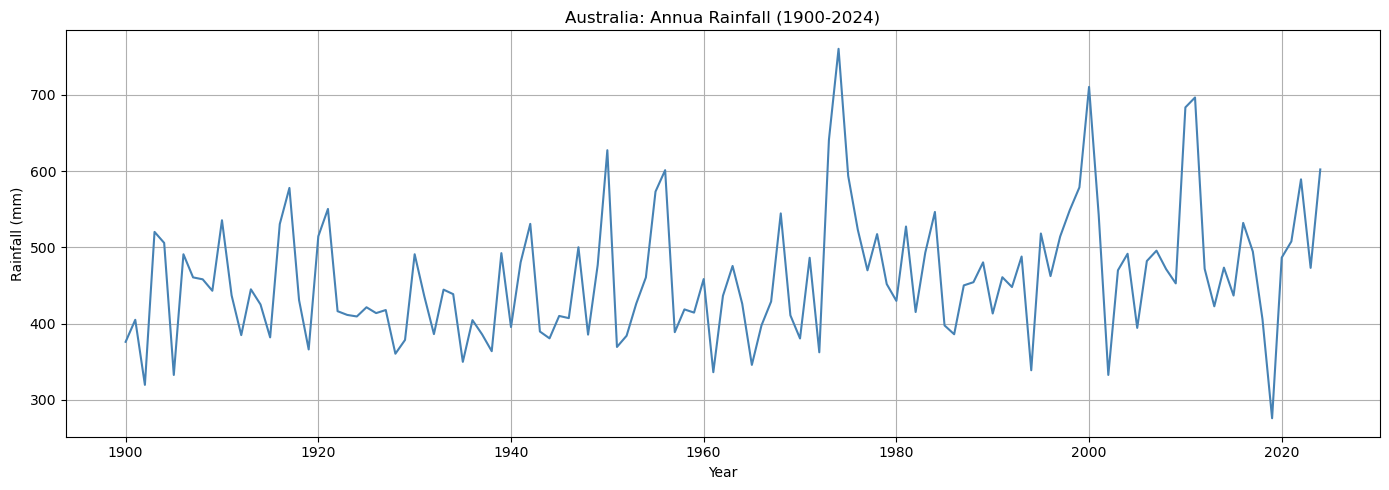

In [17]:
# Total rainfall per year
df.plot(
    x="Year",
    y="Rainfall (mm)",
    kind="line",
    figsize=(14, 5),
    color="steelblue",
    legend=False,
    title="Australia: Annua Rainfall (1900-2024)"
)
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid()
plt.tight_layout()
plt.savefig("../outputs/aus_annual_rainfall.png", dpi=300)
plt.show()

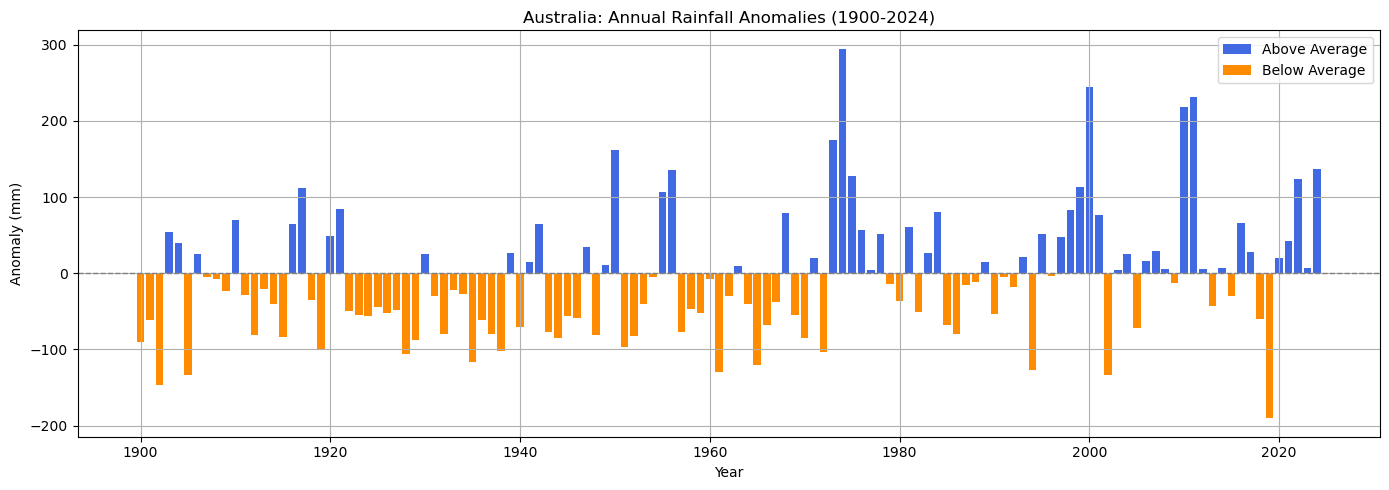

In [18]:
# Rainfall anomalies by year
plt.figure(figsize=(14, 5))
anomalies = df[["Year", "Rainfall Anomaly (mm)"]]
positive_anomalies = anomalies[anomalies["Rainfall Anomaly (mm)"] >= 0]
negative_anomalies = anomalies[anomalies["Rainfall Anomaly (mm)"] < 0]

plt.bar(positive_anomalies["Year"], positive_anomalies["Rainfall Anomaly (mm)"], color="royalblue", label="Above Average")
plt.bar(negative_anomalies["Year"], negative_anomalies["Rainfall Anomaly (mm)"], color="darkorange", label="Below Average")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.title("Australia: Annual Rainfall Anomalies (1900-2024)")
plt.xlabel("Year")
plt.ylabel("Anomaly (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/aus_annomalies_by_year.png", dpi=300)
plt.show()


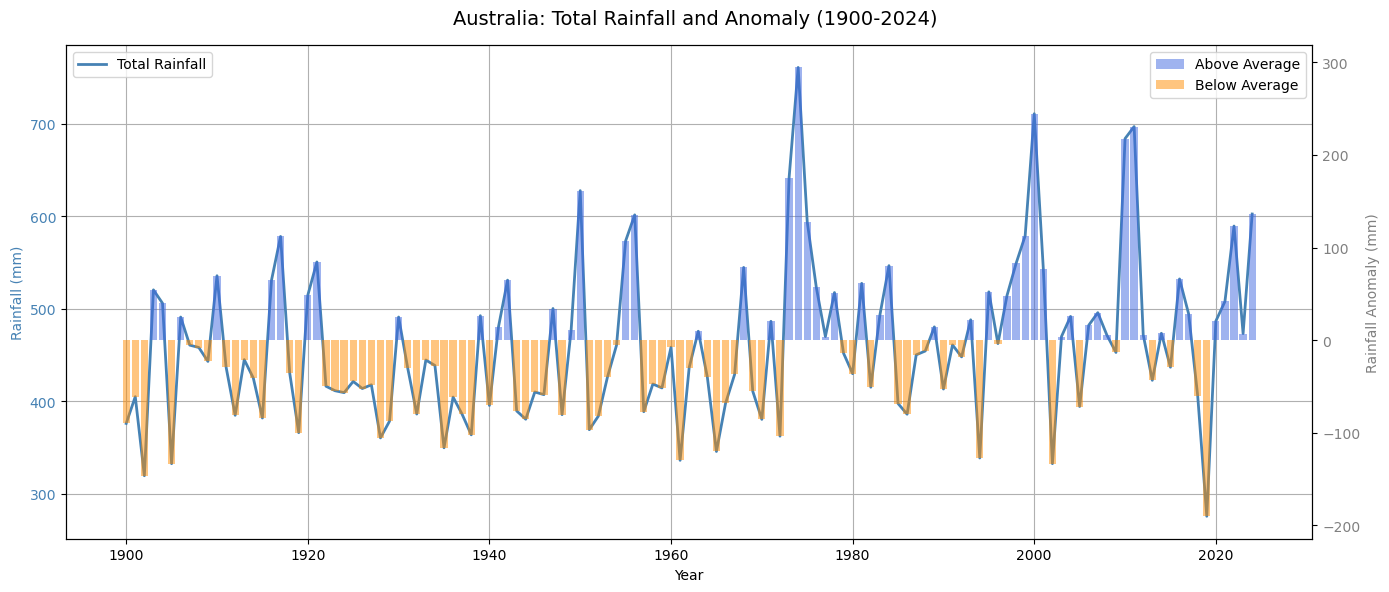

In [19]:
# Let's combine the two plots into one figure
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plotting total rainfall (1st plot)
color_rain = "steelblue"
ax1.set_xlabel("Year")
ax1.set_ylabel("Rainfall (mm)", color=color_rain)
ax1.plot(df["Year"], df["Rainfall (mm)"], color=color_rain, label="Total Rainfall", linewidth=2)
ax1.tick_params(axis="y", labelcolor=color_rain)
ax1.grid(True)

# Plotting rainfall anomalies (2nd plot y-axis)
ax2 = ax1.twinx()

color_positive = "royalblue"
color_negative = "darkorange"
ax2.bar(positive_anomalies["Year"], positive_anomalies["Rainfall Anomaly (mm)"], color=color_positive, label="Above Average", alpha=0.5)
ax2.bar(negative_anomalies["Year"], negative_anomalies["Rainfall Anomaly (mm)"], color=color_negative, label="Below Average", alpha=0.5)

ax2.set_ylabel("Rainfall Anomaly (mm)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")

fig.suptitle("Australia: Total Rainfall and Anomaly (1900-2024)", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.92) # Adjust top to make room for the title
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.savefig("../outputs/aus_combined_rainfall_and_anomalies.png", dpi=300)
plt.show()
# Save the combined plot